# Showcase — the GERD reservoir filling on the Blue Nile (2020 → 2024)

The Grand Ethiopian Renaissance Dam impounds the Blue Nile; its reservoir was filled in stages from 2020 to 2024. This notebook animates the fill with pyramids' `DatasetCollection.plot()` and measures the water-surface area each year with NDWI.

## What this notebook does

1. **Fetch** one dry-season Sentinel-2 composite per year (2020–2024).
2. **Animate** the fill with `DatasetCollection.plot()`.
3. **Measure** the reservoir's water-surface area per year with NDWI.

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`.

In [1]:
import os, tempfile, base64
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from loguru import logger
from IPython.display import HTML, display
from earthlens import EarthLens
from pyramids.dataset import Dataset, DatasetCollection   # pyramids' own plotting

logger.disable("earthlens"); logger.disable("pyramids")
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

def grab(collection, aoi, start, end, bands, scale, reducer="median"):
    """Download one GEE composite over [start, end]; return its GeoTIFF path or None."""
    el = EarthLens(data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={collection: list(bands)}, lat_lim=[aoi[1], aoi[3]], lon_lim=[aoi[0], aoi[2]],
        path=tempfile.mkdtemp(), scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001
        print("download skipped (needs GEE credentials):", exc); return None
    return str(p[0]) if p else None

def animate_collection(files, band, title, cmap=None, fps=1):
    """Animate a stack of GeoTIFFs with pyramids DatasetCollection.plot; embed as GIF."""
    glyph = DatasetCollection.from_files(files).plot(band=band, title=title, cmap=cmap)
    gif = os.path.join(tempfile.mkdtemp(), "anim.gif")
    glyph.save_animation(gif, fps=fps)
    return HTML(f'<img src="data:image/gif;base64,{base64.b64encode(open(gif,"rb").read()).decode()}" style="max-width:620px"/>')

AOI = [34.95, 11.05, 35.25, 11.32]; C = "COPERNICUS/S2_SR_HARMONIZED"

# One Nov-Dec composite per year. B4/B3/B2 true colour + B8 NIR (for NDWI).
files, labels = [], []
for y in range(2020, 2025):
    p = grab(C, AOI, f"{y}-11-01", f"{y}-12-28", ["B4", "B3", "B2", "B8"], scale=30)
    if p:
        files.append(p); labels.append(str(y))
print(f"{len(files)} yearly composites:", labels)

5 yearly composites: ['2020', '2021', '2022', '2023', '2024']


## A single year — `Dataset.plot()`

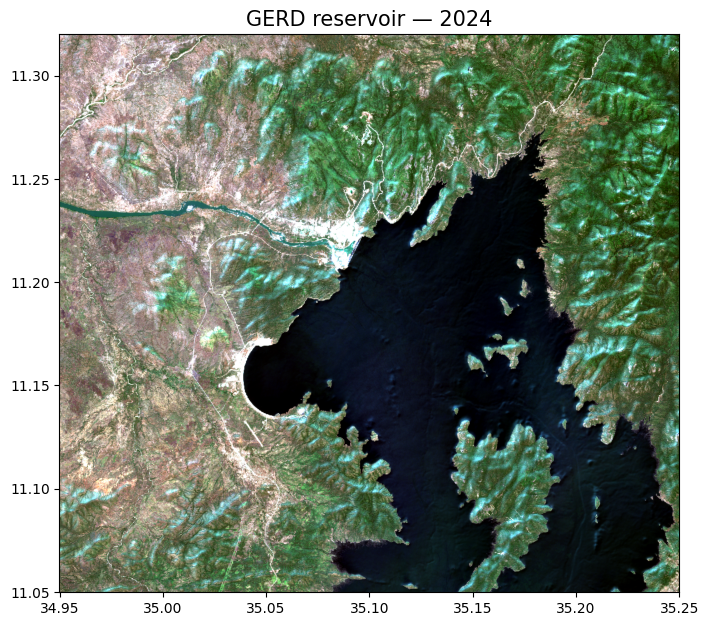

In [2]:
# pyramids true-colour render of the most recent composite.
if files:
    Dataset.read_file(files[-1]).plot(rgb_options={"rgb": [0, 1, 2], "percentile": 2},
                                      title=f"GERD reservoir — {labels[-1]}")
    plt.show()

## Animated reservoir filling — `DatasetCollection.plot()`

Animating the **NIR band (B8)** makes the open water — which is very dark in the near-infrared — stand out crisply as it grows behind the dam.


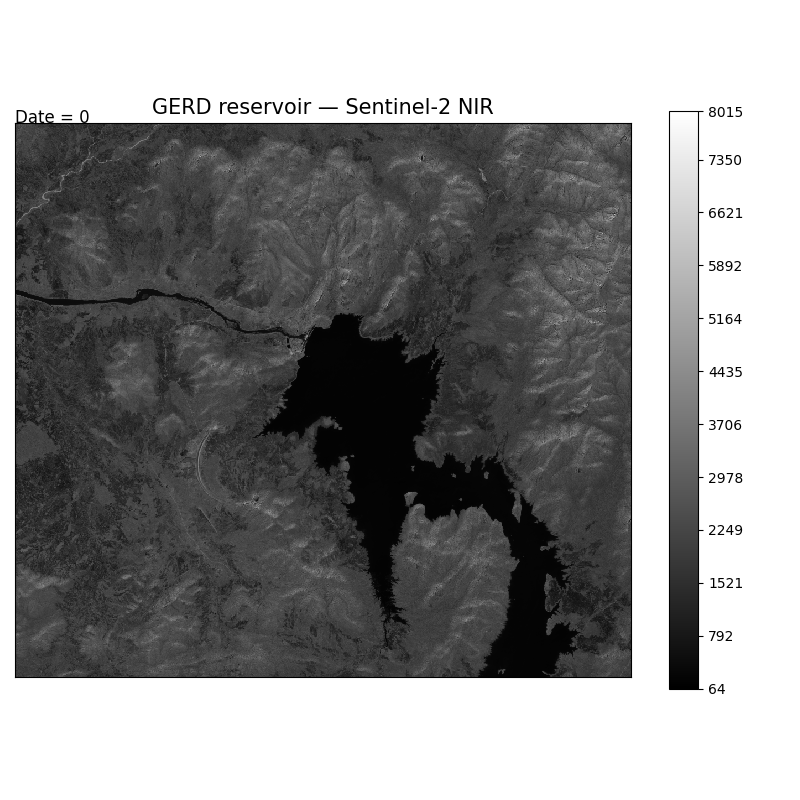

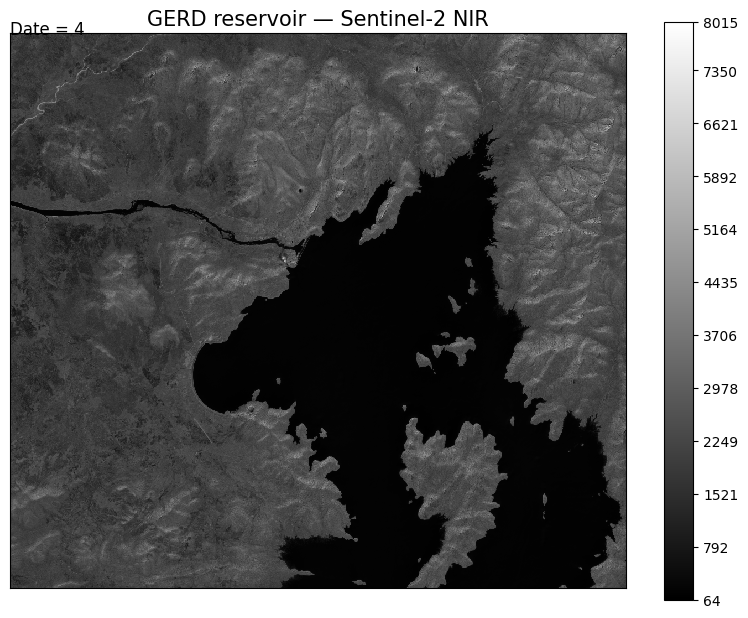

In [3]:
if files:
    display(animate_collection(files, band=3, title="GERD reservoir — Sentinel-2 NIR", cmap="gray", fps=1))
else:
    print("no scenes — set GEE credentials and rerun")

## Reservoir surface area each year (NDWI)

NDWI = (Green − NIR)/(Green + NIR) > 0 marks open water; counting those pixels gives the surface area, which climbs year on year.

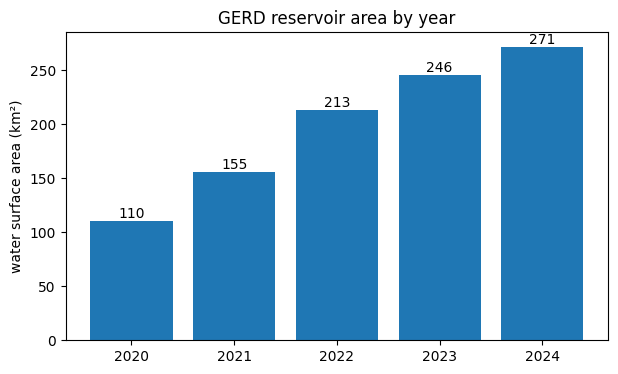

reservoir area (km²): {'2020': 110, '2021': 155, '2022': 213, '2023': 246, '2024': 271}


In [4]:
# NDWI water area per year (read arrays with pyramids, count with numpy).
if files:
    px_km2 = (30 * 30) / 1e6; areas = []
    for p in files:
        a = np.asarray(Dataset.read_file(p).read_array(), dtype="float32")
        ndwi = (a[1] - a[3]) / (a[1] + a[3] + 1e-6)
        areas.append(float(np.sum(ndwi > 0) * px_km2))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, areas, color="tab:blue")
    for i, v in enumerate(areas): ax.text(i, v, f"{v:.0f}", ha="center", va="bottom")
    ax.set(ylabel="water surface area (km²)", title="GERD reservoir area by year"); plt.show()
    print("reservoir area (km²):", {l: round(v) for l, v in zip(labels, areas)})

## Recap

`DatasetCollection.plot()` animates the fill straight from the Dataset stack; NDWI turns it into a surface-area-per-year curve.

## Try it yourself

- Animate a different band, or point `AOI` at another reservoir.
- See the [GEE backend reference](../../reference/gee/introduction.md).